# Cálculo Científico (I-2026): Taller I: Compresión de Imágenes mediante SVD
**Integrantes:** Amanda Mercedes 31708119
                 Sergio Gómez 30142272

## Parte I: Implementación Computacional
1. Cargue una imagen de alta resolución y conviértala a una matriz de intensidades de gris

In [237]:
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
from matplotlib.ticker import FuncFormatter

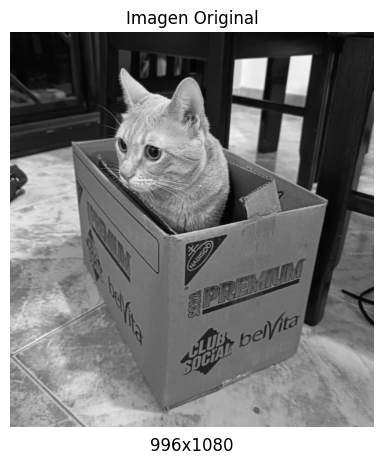

In [238]:
img = Image.open('Kirby.jpeg')
img_gray = img.convert('L')
img_mat = np.array(img_gray)
img_mat = img_mat.astype(float)
ancho, alto = img.size

fig, ax = plt.subplots()
ax.imshow(img_mat, cmap='gray')
ax.set_title("Imagen Original")
fig.suptitle(f"{ancho}x{alto}", y=0.01)

ax.axis('off')

plt.tight_layout()
plt.show()

2. Calcule la SVD de la matriz resultante

In [239]:
u, s, vt = np.linalg.svd(img_mat)

3. Construya aproximaciones $A_k$ para valores de $k \in {5, 20, 50, 100, 200}$.

In [240]:
k_vals = [5, 20, 50, 100, 200]
a_k_mats = []

for k in k_vals:
    a_k = u[:, :k] * s[:k] @ vt[:k, :]
    a_k_mats.append(a_k)

4. Visualice las reconstrucciones y compare visualmente la calidad respecto al original.

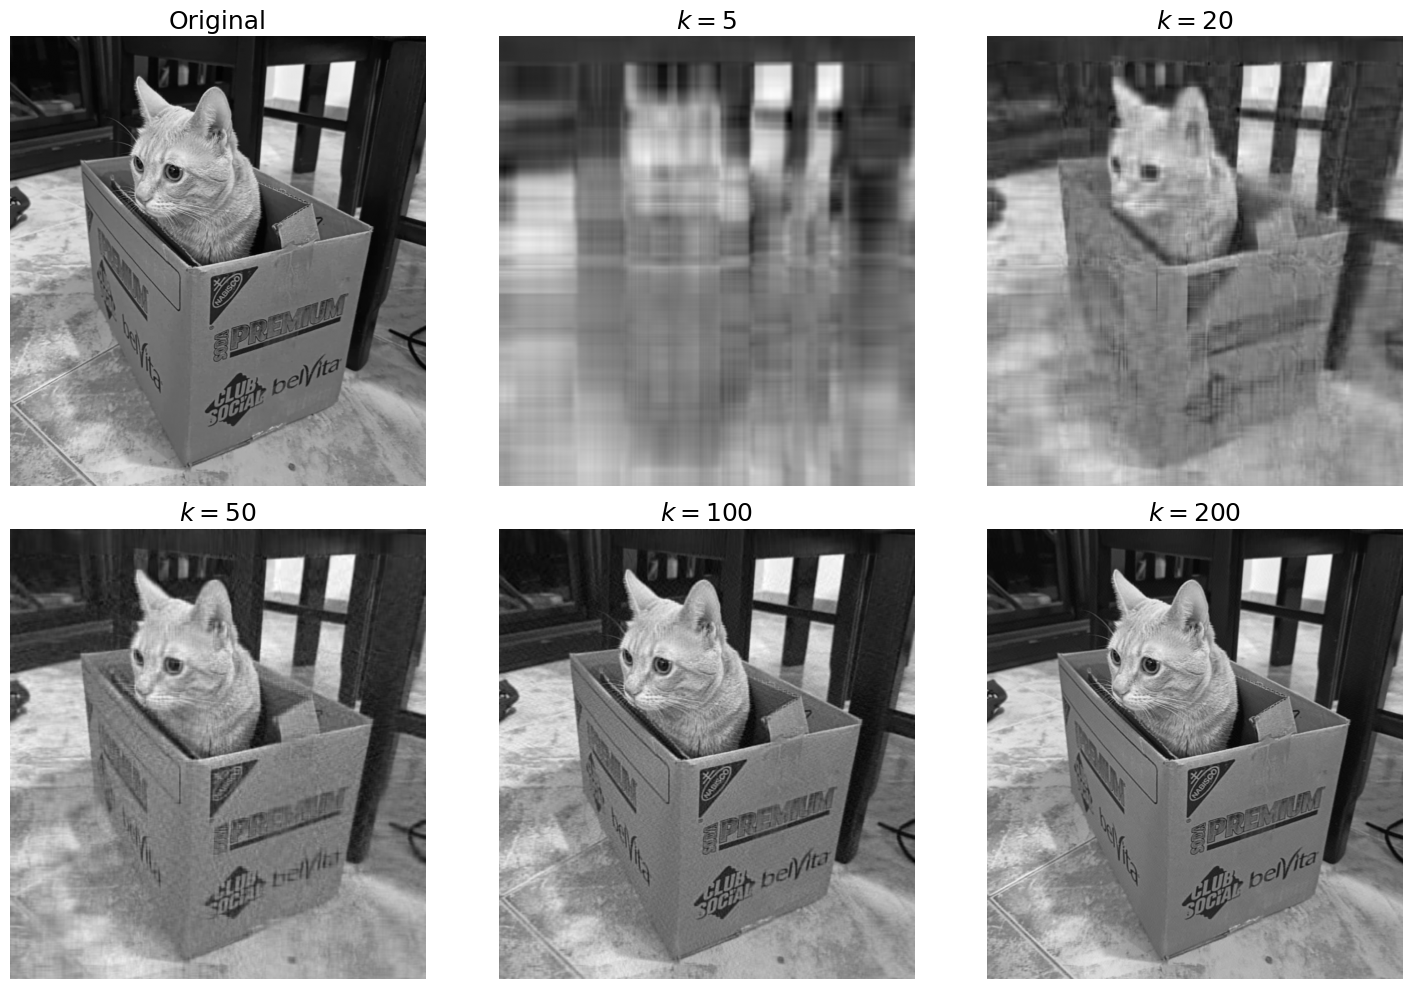

In [241]:
fig, axes = plt.subplots(2, 3, figsize=(15, 10))

ax_f = axes.flatten()

ax_f[0].imshow(img_mat, cmap='gray')
ax_f[0].set_title("Original", fontsize=18)
ax_f[0].axis('off')

for i, k in enumerate(k_vals):
    A_k = a_k_mats[i]
    
    ax_f[i+1].imshow(A_k, cmap='gray')
    ax_f[i+1].set_title(f"$k = {k}$", fontsize=18)
    ax_f[i+1].axis('off')

plt.tight_layout()
fig.savefig("comp.pdf", bbox_inches='tight')
plt.show()

## Parte II: Análisis Cuantitativo
1. **Tasa de Compresión**: Calcule la relación de almacenamiento entre la matriz original ($m\times n$) y los datos necesarios para $A_k$, dados por $k(m + n + 1)$.

In [242]:
tasas_compresion = {}
for k in k_vals:
    tasa = (ancho * alto) / (k * (ancho + alto + 1))
    tasas_compresion[k] = tasa

print(tasas_compresion)

{5: 103.58016369764083, 20: 25.895040924410207, 50: 10.358016369764083, 100: 5.179008184882042, 200: 2.589504092441021}


2. **Análisis de Error**: Grafique el error relativo $\|A − A_k \|F / \|A\|F$ frente al número de valores
singulares utilizados ($k$).

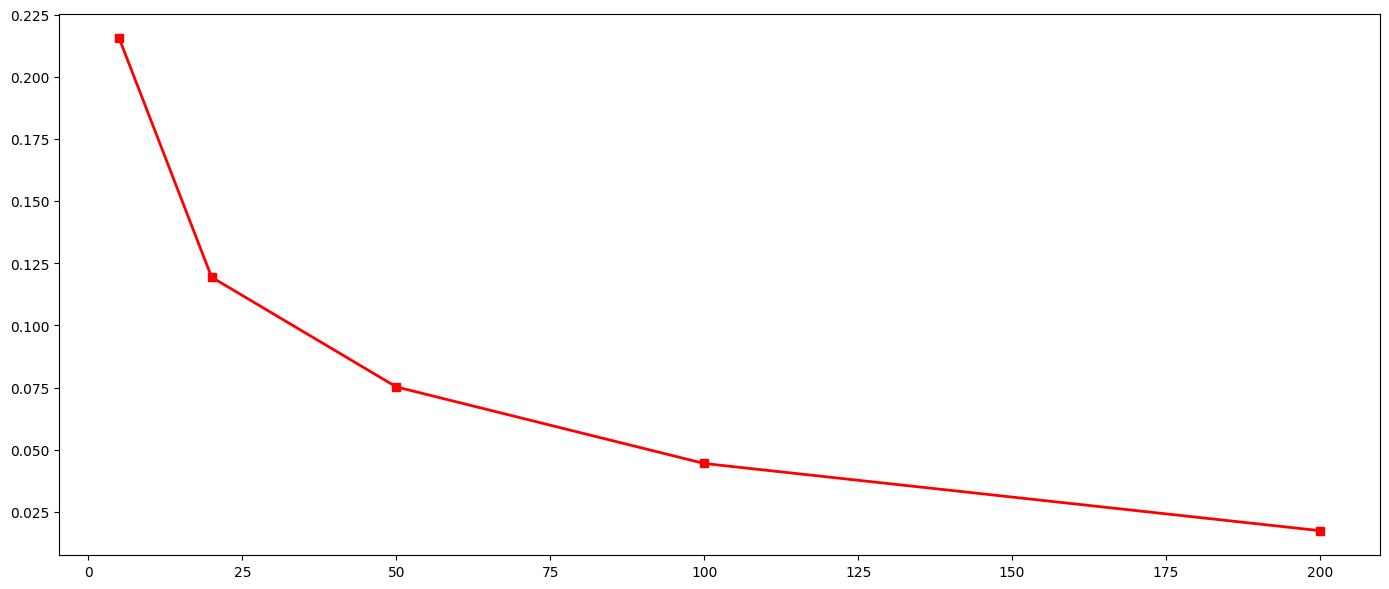

In [243]:
s_cuadrado = s ** 2

a_frob = np.sqrt(np.sum(s_cuadrado))

e_rel = []

for k in k_vals:
    e_abs = np.sqrt(np.sum(s_cuadrado[k:]))
    e_rel.append(e_abs / a_frob)


fig, ax = plt.subplots(1, 1, figsize=(14, 6))

ax.plot(k_vals, e_rel, color='red', marker='s', linestyle='-', linewidth=2)

plt.tight_layout()

plt.show()


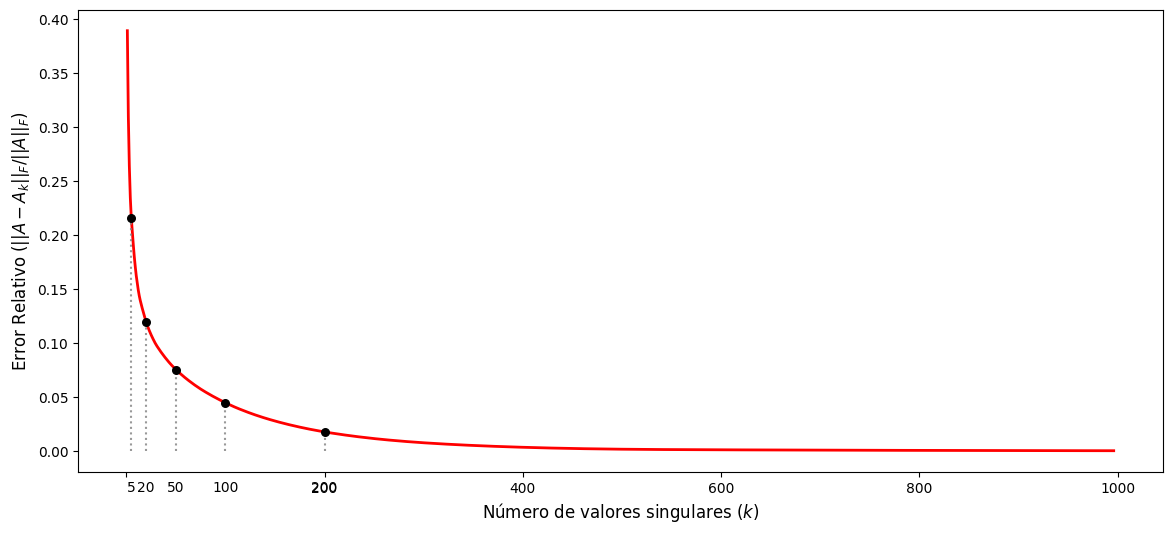

In [244]:
fig, ax = plt.subplots(1, 1, figsize=(14, 6))

e_rel_test = []

for k in range(1, min(ancho, alto) + 1):
    e_abs = np.sqrt(np.sum(s_cuadrado[k:]))
    e_rel_test.append(e_abs / a_frob)

ax.plot(range(1, min(ancho, alto) + 1), e_rel_test, color='red', linestyle='-', linewidth=2)

errores_marcados = [e_rel_test[k - 1] for k in k_vals]

ax.scatter(k_vals, errores_marcados, color='black', s=30, zorder=5)

for i, k in enumerate(k_vals):
    ax.vlines(x=k, ymin=0, ymax=errores_marcados[i], color='gray', linestyle=':', alpha=0.8)

    ax.text(k, -0.02, f"{k}", transform=ax.get_xaxis_transform(), 
            ha='center', va='top', color='black', fontsize=10)
    
ax.xaxis.set_major_formatter(FuncFormatter(lambda x, pos: "" if x == 0 else f"{int(x)}"))
ax.set_xlabel("Número de valores singulares ($k$)", fontsize=12)
ax.set_ylabel("Error Relativo ($||A - A_k||_F / ||A||_F$)", fontsize=12)
plt.show()


3. **Energı́a**: Grafique el porcentaje de la “energı́a” (varianza) capturada, definida como:

$$E(k)= \frac{\sum^k_{i=1} \sigma_i^2}{\sum^r_{i=1} \sigma_i^2}$$

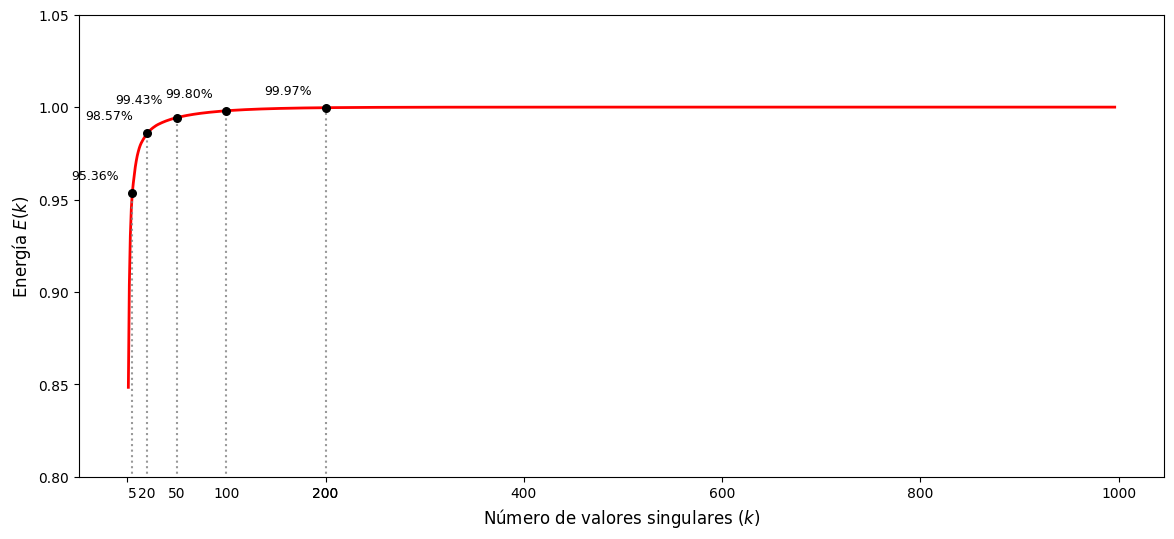

In [245]:
energia_total = np.sum(s_cuadrado)
energia_acumulada = np.cumsum(s_cuadrado)
energia = energia_acumulada / energia_total

fig, ax = plt.subplots(1, 1, figsize=(14, 6))
ax.plot(range(1, min(ancho, alto) + 1), energia, color= "red", linestyle='-', linewidth=2)
energias_marcadas = [energia[k - 1] for k in k_vals]
ax.scatter(k_vals, energias_marcadas, color='black', s=30, zorder=5)
for i, k in enumerate(k_vals):
    ax.vlines(x=k, ymin=0, ymax=energias_marcadas[i], color='gray', linestyle=':', alpha=0.8)
    
    ax.text(k, -0.02, f"{k}", transform=ax.get_xaxis_transform(), 
            ha='center', va='top', color='black', fontsize=10)

    # Opcional: Agregar el porcentaje de la energía un poco más arriba del punto
    ax.annotate(f"{energias_marcadas[i]:.2%}", 
                (k, energias_marcadas[i]), 
                textcoords="offset points", 
                xytext=(-10, 10), 
                ha='right', 
                fontsize=9)
ax.xaxis.set_major_formatter(FuncFormatter(lambda x, pos: "" if x == 0 else f"{int(x)}"))
ax.set_ylim(0.80, 1.05)
ax.set_xlabel("Número de valores singulares ($k$)", fontsize=12)
ax.set_ylabel("Energía $E(k)$", fontsize=12)
plt.show()

### Bonus: imagen a color

1. Separamos la imagen en sus tres componentes fundamentales: Rojo, verde y azul

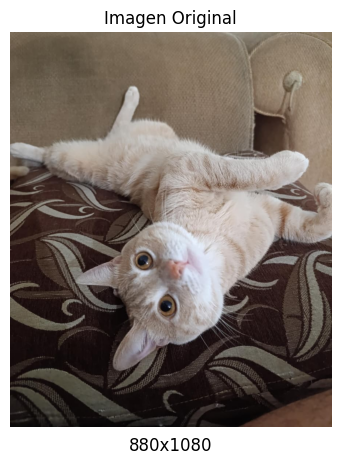

In [249]:
img_color= Image.open('Kirby a color.jpeg')
ancho_color, alto_color = img_color.size
fig, ax = plt.subplots()
ax.imshow(img_color)
ax.set_title("Imagen Original")
fig.suptitle(f"{ancho_color}x{alto_color}", y=0.01)
ax.axis('off')
plt.tight_layout()
plt.show()


In [ ]:
img_array = np.array(img_color)
R = img_array[:, :, 0]
G = img_array[:, :, 1]
B = img_array[:, :, 2]

ur, sr, vtr = np.linalg.svd(R)
ug, sg, vtg = np.linalg.svd(G)
ub, sb, vtb = np.linalg.svd(B)

k_vals = [5, 20, 50, 100, 200]
a_k_mats = []

for k in k_vals:
    r_k = ur[:, :k] * sr[:k] @ vtr[:k, :]
    g_k = ug[:, :k] * sg[:k] @ vtg[:k, :]
    b_k = ub[:, :k] * sb[:k] @ vtb[:k, :]
    
    img_k = np.stack((r_k, g_k, b_k), axis=2) #para unir los 3 canales (rojo, azul y verde) en una matriz 3D
    img_k = np.clip(img_k, 0, 255) / 255.0 #hay que normalizar la imagen para ptl
    
    a_k_mats.append(img_k)

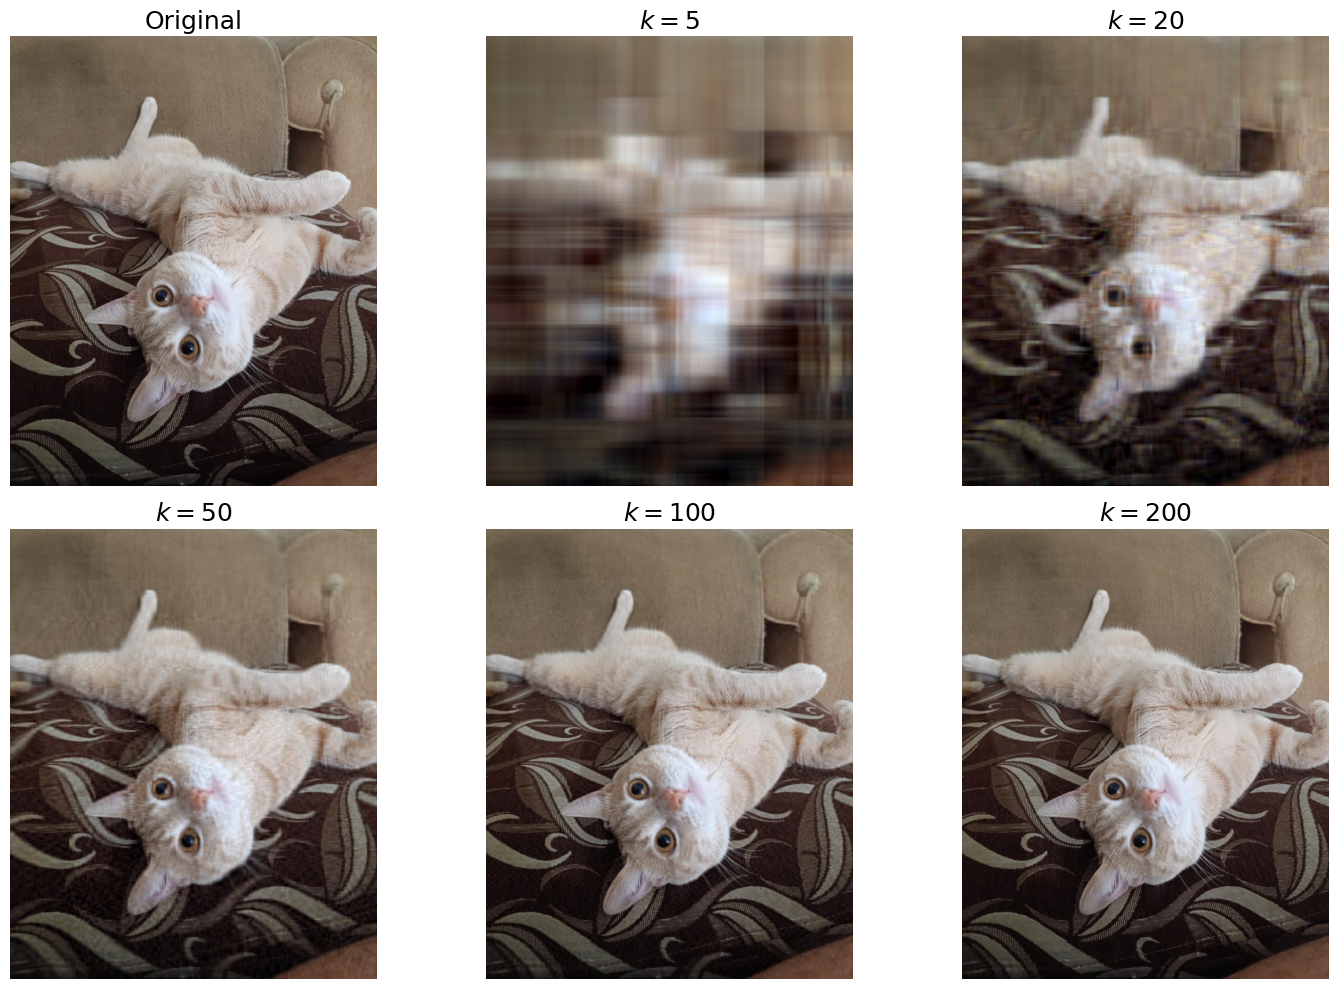

In [248]:
fig, axes = plt.subplots(2, 3, figsize=(15, 10))

ax_f = axes.flatten()

ax_f[0].imshow(img_color)
ax_f[0].set_title("Original", fontsize=18)
ax_f[0].axis('off')

for i, k in enumerate(k_vals):
    A_k = a_k_mats[i]
    
    ax_f[i+1].imshow(A_k)
    ax_f[i+1].set_title(f"$k = {k}$", fontsize=18)
    ax_f[i+1].axis('off')

plt.tight_layout()
fig.savefig("comp_color.pdf", bbox_inches='tight')
plt.show()

In [250]:
tasas_compresion = {}
for k in k_vals:
    tasa = (ancho_color * alto_color) / (k * (ancho_color + alto_color + 1))
    tasas_compresion[k] = tasa

print(tasas_compresion)

{5: 96.93013768485467, 20: 24.232534421213668, 50: 9.693013768485466, 100: 4.846506884242733, 200: 2.4232534421213665}


Text(0, 0.5, 'Error Relativo RGB ($||A - A_k||_F / ||A||_F$)')

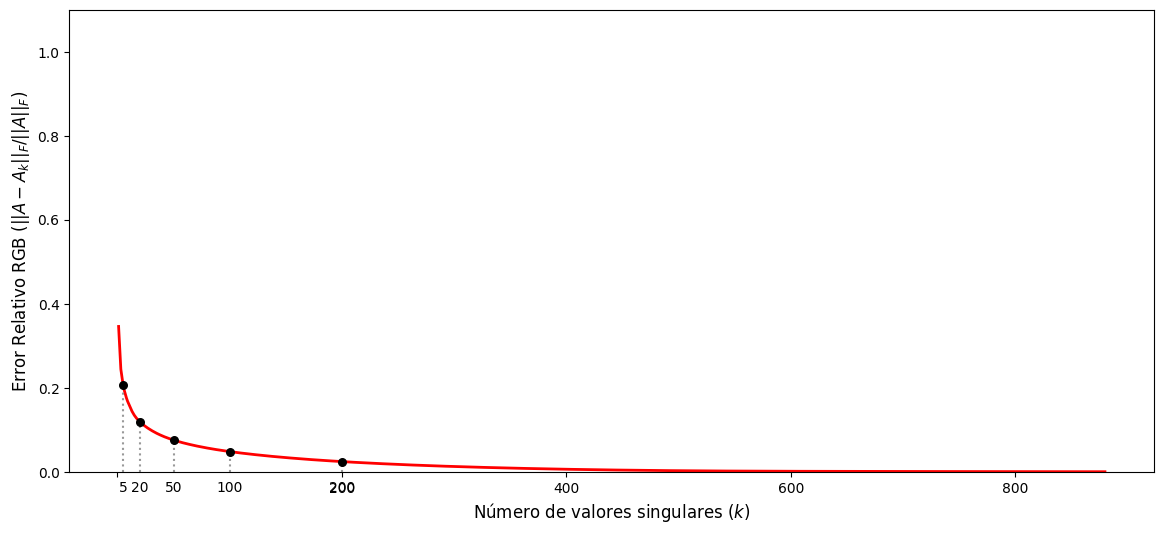

In [252]:
sr_cuadrado = sr**2
sg_cuadrado = sg**2
sb_cuadrado = sb**2

frob_color = np.sqrt(np.sum(sr_cuadrado) + np.sum(sg_cuadrado) + np.sum(sb_cuadrado))

fig, ax = plt.subplots(1, 1, figsize=(14, 6))

e_rel_test = []

for k in range(1, min(ancho, alto) + 1):
    error_descartado = np.sum(sr_cuadrado[k:]) + np.sum(sg_cuadrado[k:]) + np.sum(sb_cuadrado[k:])
    e_abs = np.sqrt(error_descartado)
    e_rel_test.append(e_abs / frob_color)

ax.plot(range(1, min(ancho, alto) + 1), e_rel_test, color='red', linestyle='-', linewidth=2)

errores_marcados = [e_rel_test[k - 1] for k in k_vals]

ax.scatter(k_vals, errores_marcados, color='black', s=30, zorder=5)

for i, k in enumerate(k_vals):
    ax.vlines(x=k, ymin=0, ymax=errores_marcados[i], color='gray', linestyle=':', alpha=0.8)

    ax.text(k, -0.02, f"{k}", transform=ax.get_xaxis_transform(), 
            ha='center', va='top', color='black', fontsize=10)
    
ax.xaxis.set_major_formatter(FuncFormatter(lambda x, pos: "" if x == 0 else f"{int(x)}"))
ax.set_ylim(0, 1.1)
ax.set_xlabel("Número de valores singulares ($k$)", fontsize=12)
ax.set_ylabel("Error Relativo RGB ($||A - A_k||_F / ||A||_F$)", fontsize=12)

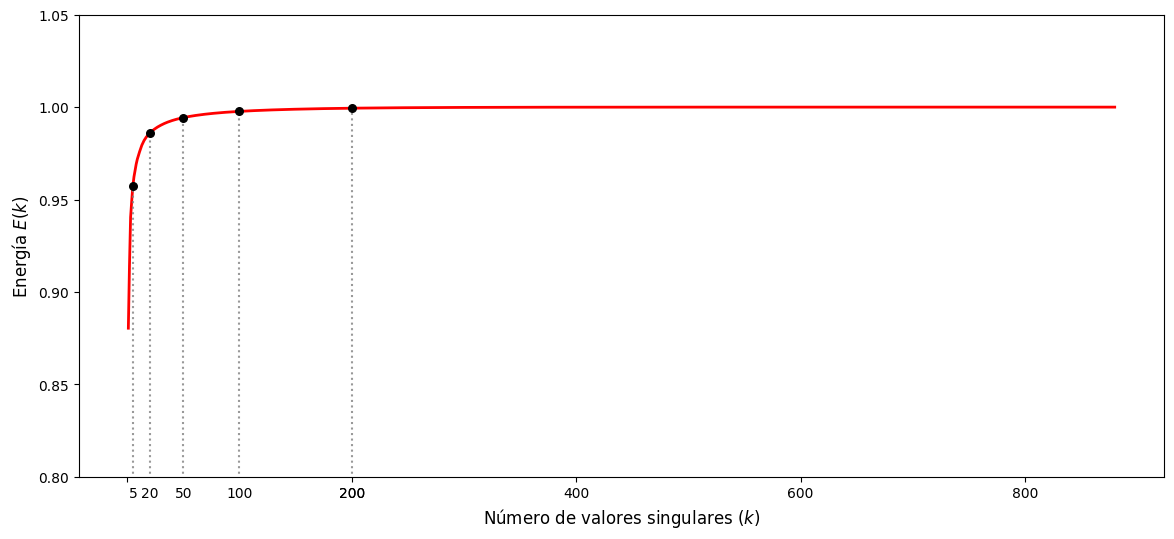

In [253]:
s_cuadrado_color = (sr**2) + (sg**2) + (sb**2)
energia = np.cumsum(s_cuadrado_color) / np.sum(s_cuadrado_color)

fig, ax = plt.subplots(1, 1, figsize=(14, 6))
ax.plot(range(1, min(ancho, alto) + 1), energia, color="red", linestyle='-', linewidth=2)

energias_marcadas = [energia[k - 1] for k in k_vals]

ax.scatter(k_vals, energias_marcadas, color='black', s=30, zorder=5)

for i, k in enumerate(k_vals):
    ax.vlines(x=k, ymin=0, ymax=energias_marcadas[i], color='gray', linestyle=':', alpha=0.8)
    
    ax.text(k, -0.02, f"{k}", transform=ax.get_xaxis_transform(), 
            ha='center', va='top', color='black', fontsize=10)
    
ax.xaxis.set_major_formatter(FuncFormatter(lambda x, pos: "" if x == 0 else f"{int(x)}"))
ax.set_ylim(0.80, 1.05)
ax.set_xlabel("Número de valores singulares ($k$)", fontsize=12)
ax.set_ylabel("Energía $E(k)$", fontsize=12)

plt.show()

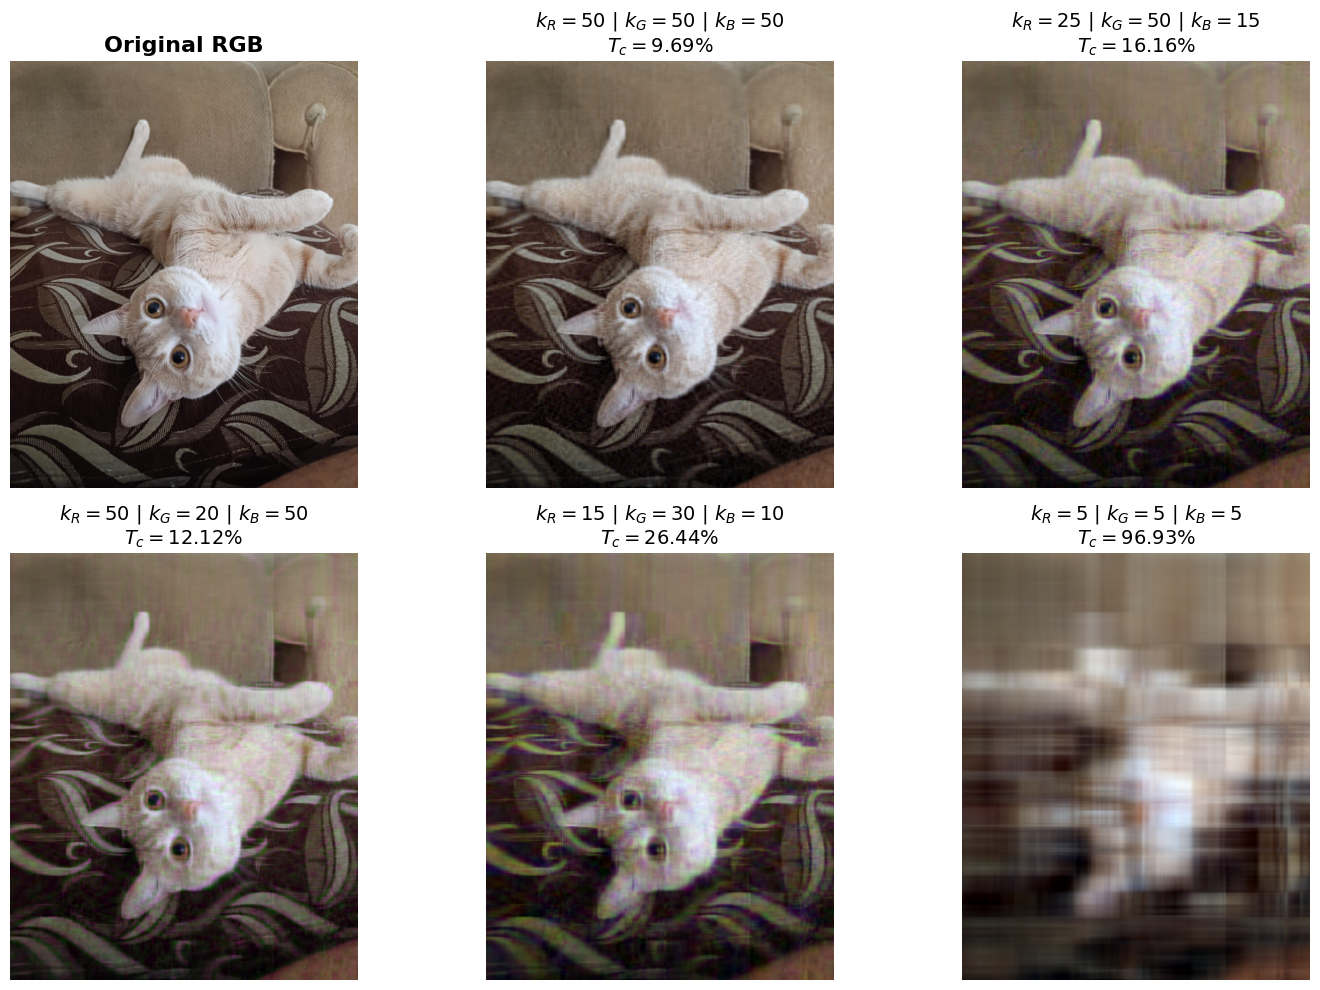

In [265]:
escenarios_k = [
    (50, 50, 50),  
    (25, 50, 15),  
    (50, 20, 50),  
    (15, 30,  10),  
    ( 5,  5,  5)   
]
elementos_originales = 3 * alto_color * ancho_color
fig, axes = plt.subplots(2, 3, figsize=(15, 10))
ax_f = axes.flatten()

ax_f[0].imshow(img_color)
ax_f[0].set_title("Original RGB", fontsize=16, fontweight='bold')
ax_f[0].axis('off')

for i, (kr, kg, kb) in enumerate(escenarios_k):
    
   
    r_k = ur[:, :kr] * sr[:kr] @ vtr[:kr, :]
    g_k = ug[:, :kg] * sg[:kg] @ vtg[:kg, :]
    b_k = ub[:, :kb] * sb[:kb] @ vtb[:kb, :]
    
    
    img_k = np.stack((r_k, g_k, b_k), axis=2)
    if img_k.max() > 2.0:
        img_k = img_k / 255.0
        
    img_k = np.clip(img_k, 0.0, 1.0)
    
    elementos_comprimidos = (kr + kg + kb) * (alto_color + ancho_color + 1)
    
    tc_porcentaje = (elementos_originales/elementos_comprimidos)
    
    
    ax_f[i+1].imshow(img_k)
    
    ax_f[i+1].set_title(f"$k_R={kr}$ | $k_G={kg}$ | $k_B={kb}$\n$T_c = {tc_porcentaje:.2f}\%$", fontsize=14)
    ax_f[i+1].axis('off')

plt.tight_layout()
fig.savefig("compresion_asimetrica.pdf", bbox_inches='tight')
plt.show()